In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from calibration import load_data, separate_ch_sig, rectify, bandpass_filter, lowpass_filter

In [2]:
# load the raw and filtered data for comparison
dir = dir = r"C:\Users\Maryam\OneDrive - UW\Quals\stimActive-test\2025 - 10 - 24\modifiedMTS"
date_timestamp = "2025 - 10 - 24_11 - 18 - 32"
file_extension = ".csv"

_raw = r"\MTS_Test_RawFormattedEMGData_" + date_timestamp + file_extension
_filt = r"\MTS_Test_FiltEMGData_" + date_timestamp + file_extension
_env = r"\MTS_Test_EnvData_" + date_timestamp + file_extension

raw = pd.read_csv(dir + _raw)
rr_filt = pd.read_csv(dir + _filt)
rr_env = pd.read_csv(dir + _env)

rr_filt_emg1 = []
rr_env_emg1 = []
r_stim = []
r_thresh = []
for i, ch in enumerate(rr_filt["emg channel"]):
    if ch == 1:
        rr_filt_emg1.append(rr_filt["filt signal"][i]*1000)

for i, ch in enumerate(rr_env["emg channel"]):
    if ch == 1:
        rr_env_emg1.append(rr_env["enveloped signal"][i]*1000)
        r_stim.append(rr_env["stim command"][i])
        r_thresh.append(rr_env["threshold"][i]*1000)

In [3]:
date_timestamp = "2025-10-24_11-18-32"
neuro_raw = r"\mtsLog_" + date_timestamp + file_extension
n_raw = pd.read_csv(dir + neuro_raw)


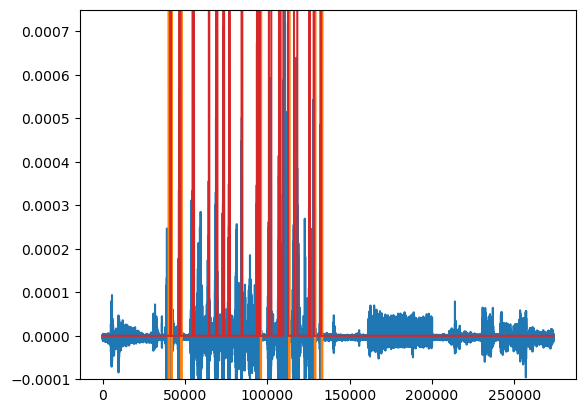

In [4]:
width = 800
height = 200
# plt.figure(figsize=(width, height))
low = 0
high = len(raw.EMG1)
# high = len(raw.EMG1)
plt.plot(np.arange(low,high), raw.EMG1[low:high])
plt.plot(np.arange(low,high), rr_env_emg1[low:high])

plt.plot(np.arange(low,high), r_thresh[low:high])
plt.plot(np.arange(low,high), r_stim[low:high])
plt.ylim([-0.0001, 0.00075])
plt.show()

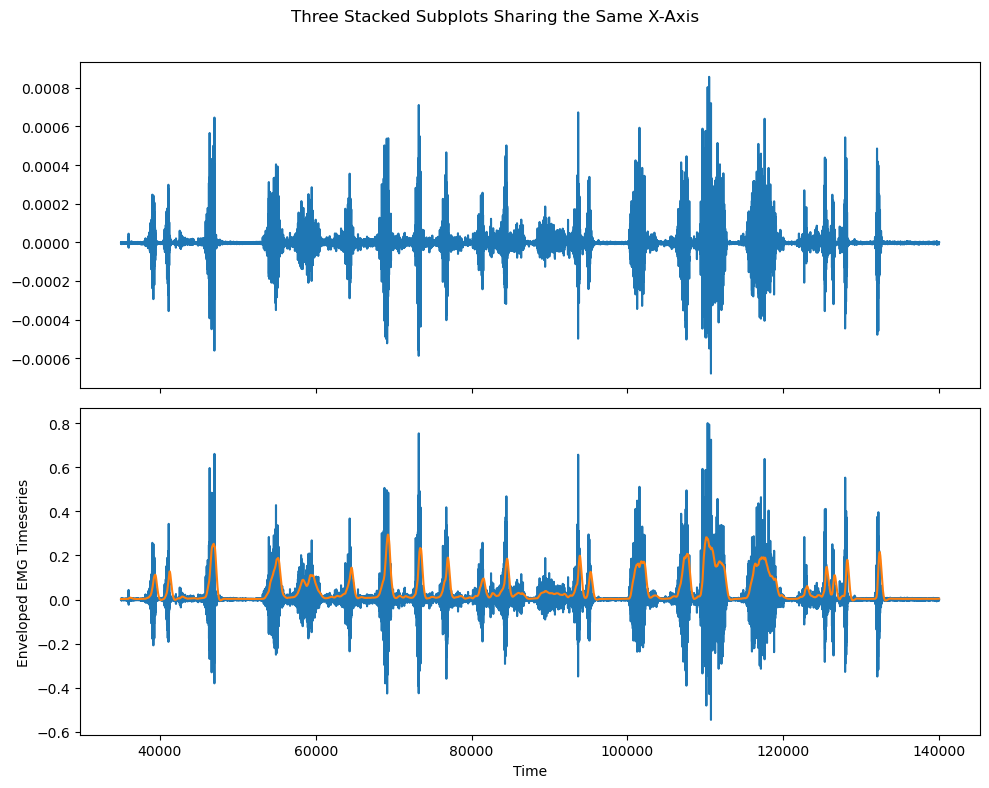

In [5]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 8))
low = 35000
high = 140000
# Plot each subplot
axs[0].plot(np.arange(low,high), raw.EMG1[low:high])
axs[1].plot(np.arange(low,high), rr_filt_emg1[low:high])

axs[1].plot(np.arange(low,high), rr_env_emg1[low:high])
axs[1].set_ylabel('Enveloped EMG Timeseries')
axs[1].set_xlabel('Time')

# Add a common title and adjust spacing
fig.suptitle('Three Stacked Subplots Sharing the Same X-Axis')
plt.tight_layout(rect=[0, 0, 1, 0.97])

In [6]:
print(len(raw.EMG1)/2)
print(len(n_raw.CH1)-len(raw.EMG1)/2)


136861.0
16339.0


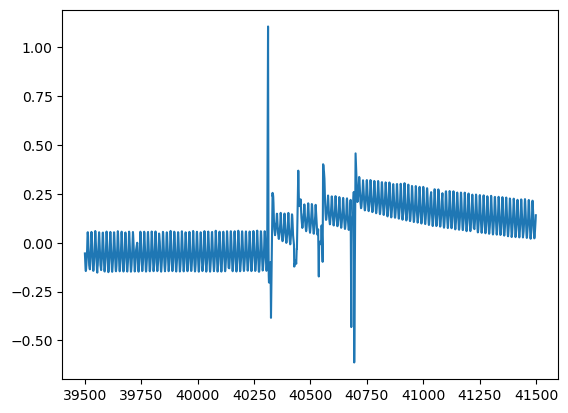

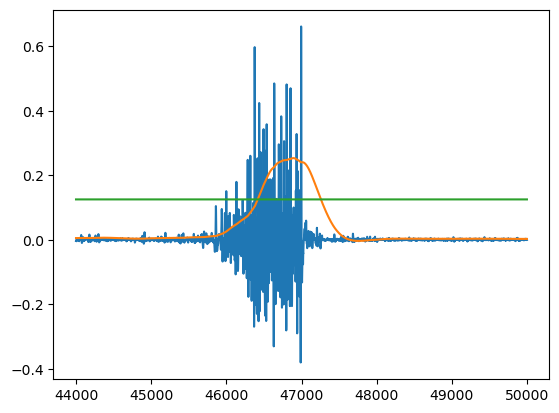

In [7]:
# plt.figure(figsize=(width, height))
s = 9
# plt.plot(np.arange(low+s*1000,round((high+s*1000)/1.5)), n_raw.CH1[low+s*1000:round((high+s*1000)/1.5)])
l= 39500
h = 41500
plt.plot(np.arange(l,h),n_raw.CH1[l:h]/10000)
plt.show()
plt.plot(np.arange(44000,50000), rr_filt_emg1[44000:50000])
plt.plot(np.arange(44000,50000), rr_env_emg1[44000:50000])
plt.plot(np.arange(44000,50000), r_thresh[44000:50000])


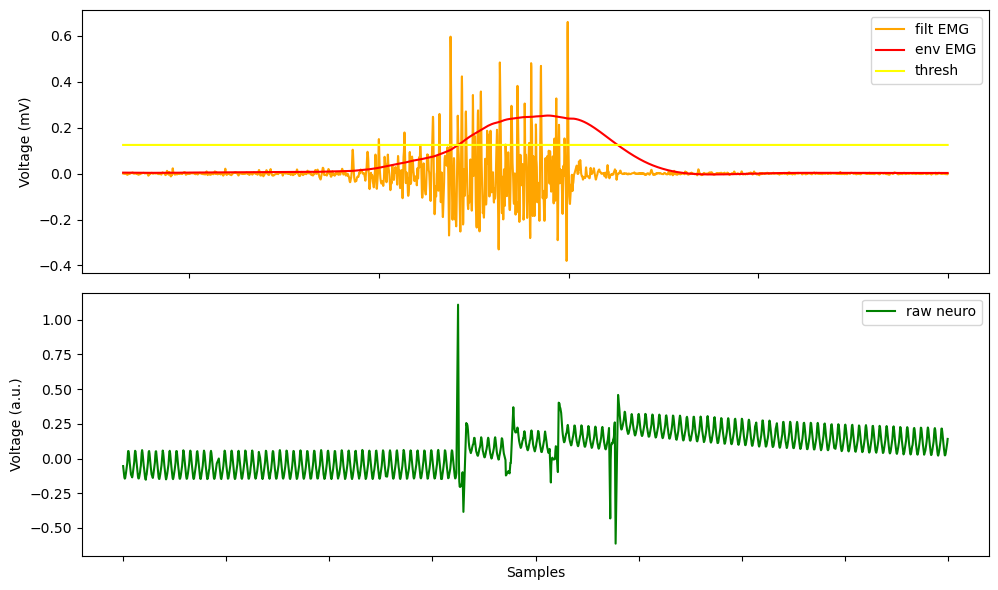

In [ ]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,           # 3 rows, 1 column
    sharex=False,   # default (we'll specify sharing manually)
    figsize=(10, 6)
)
low = 44650
high = 49000
l= 39500
h = 41500
ax1.plot(np.arange(low,high), rr_filt_emg1[low:high], label="filt EMG", color="orange")
ax1.plot(np.arange(low,high), rr_env_emg1[low:high], label="env EMG", color="red")
ax1.plot(np.arange(low,high), r_thresh[low:high], label="thresh", color="yellow")
# ax1.set_ylim([-0.00075,0.0009]*1000)
ax2.plot(np.arange(l,h),n_raw.CH1[l:h]/10000, label="raw neuro", color="green")
for ax in (ax1, ax2):
    ax.legend()
    # ax.grid(True)
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)    
# ax1.set_title("Movement Triggered Single Pulse Stimulation of CorTec BIC")
ax1.set_ylabel("Voltage (mV)")
ax2.set_ylabel("Voltage (a.u.)")
ax2.set_xlabel("Samples")
plt.tight_layout()
# plt.savefig(r"C:\Users\Maryam\Desktop\closeUp.png",dpi=400)
plt.show()

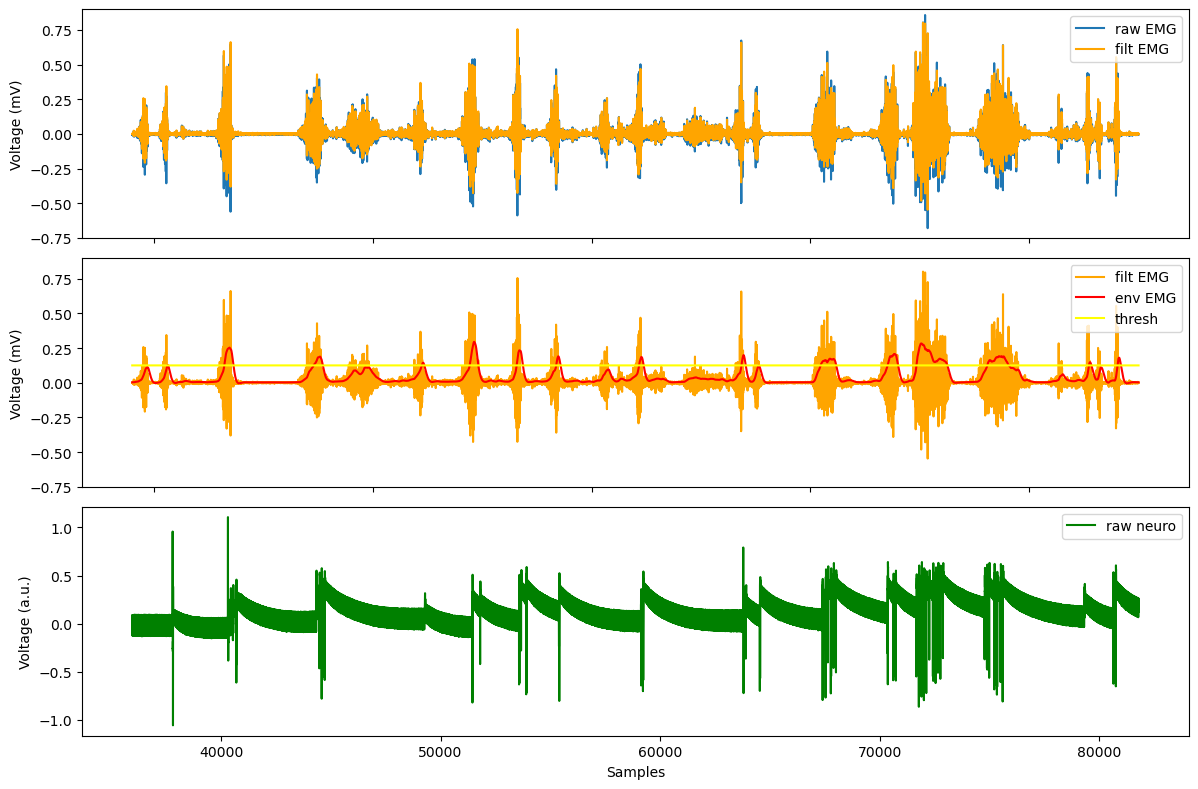

In [ ]:

low = 38000
high = 130000

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,           # 3 rows, 1 column
    sharex=False,   # default (we'll specify sharing manually)
    figsize=(12, 8)
)
# Manually link ax1 and ax2's x-axes
ax2.sharex(ax1)
s =1.5
# Plot data
ax1.plot(np.arange(low,high), raw.EMG1[low:high]*1000, label="raw EMG")
ax1.plot(np.arange(low,high), rr_filt_emg1[low:high], label="filt EMG", color="orange")
ax1.set_ylim([-.75,0.9])
ax2.plot(np.arange(low,high), rr_filt_emg1[low:high], label="filt EMG", color="orange")
ax2.plot(np.arange(low,high), rr_env_emg1[low:high], label="env EMG", color="red")
ax2.plot(np.arange(low,high), r_thresh[low:high], label="thresh", color="yellow")
ax2.set_ylim([-0.75,0.9])
# ax3.plot(np.arange(low+int(round(s*1000)),int(round((high+s*1000)/1.5))), n_raw.CH1[low+int(round(s*1000)):int(round((high+s*1000)/1.5))], label="raw neuro", color="green")
l = 35950
h = 81800
ax3.plot(n_raw.CH1[l:h]/10000, label="raw neuro", color="green")
ax3.set_xlabel("Samples")

# Add titles and legends
# ax1.set_title("Movement Triggered Single Pulse Stimulation of CorTec BIC")
ax1.set_ylabel("Voltage (mV)")
ax2.set_ylabel("Voltage (mV)")
ax3.set_ylabel("Voltage (a.u.)")
ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
# ax3.tick_params(labelbottom=False)


for ax in (ax1, ax2, ax3):
    ax.legend(loc="upper right")
    # ax.grid(True)

plt.tight_layout()
# plt.savefig(r"C:\Users\Maryam\Desktop\entire_sesh2.png",dpi=400)
plt.show()


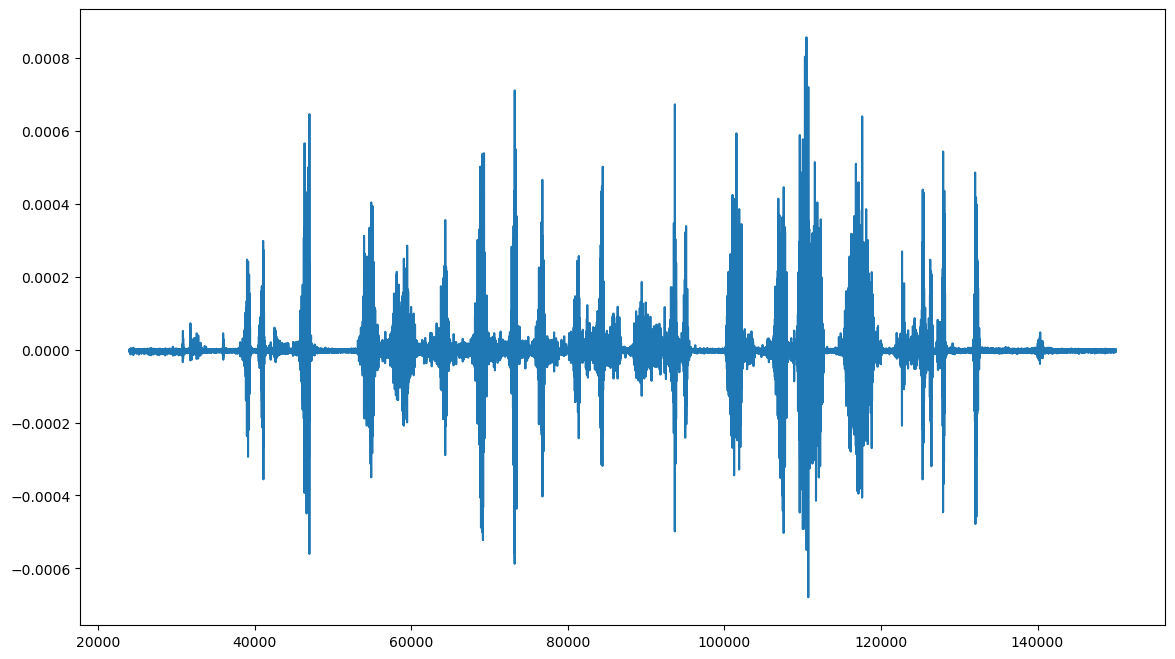

In [43]:
plt.figure(figsize=(14,8))
plt.plot(raw.EMG1[24000:150000])

In [ ]:
low = 0
high = len(raw.EMG1) -10000

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,           # 3 rows, 1 column
    sharex=False,   # default (we'll specify sharing manually)
    figsize=(8, 8)
)
# Manually link ax1 and ax2's x-axes
ax2.sharex(ax1)
s =1.5
# Plot data
ax1.plot(np.arange(low,high), raw.EMG1[low:high], label="raw EMG")
ax1.plot(np.arange(low,high), rr_filt_emg1[low:high], label="filt EMG", color="orange")
ax1.set_ylim([-0.00075,0.0008])
ax2.plot(np.arange(low,high), rr_filt_emg1[low:high], label="filt EMG", color="orange")
ax2.plot(np.arange(low,high), rr_env_emg1[low:high], label="env EMG", color="red")
ax2.plot(np.arange(low,high), r_thresh[low:high], label="thresh", color="yellow")
ax2.set_ylim([-0.00075,0.0008])
# ax3.plot(np.arange(low+int(round(s*1000)),int(round((high+s*1000)/1.5))), n_raw.CH1[low+int(round(s*1000)):int(round((high+s*1000)/1.5))], label="raw neuro", color="green")
ax3.plot(n_raw.CH1[1000*12:-1], label="raw neuro", color="green")
ax3.set_xlabel("Time")

# Add titles and legends
ax1.set_title("Movement Triggered Single Pulse Stimulation of CorTec BIC")

ax1.tick_params(labelbottom=False)
ax2.tick_params(labelbottom=False)
ax3.tick_params(labelbottom=False)


for ax in (ax1, ax2, ax3):
    ax.legend()
    # ax.grid(True)

plt.tight_layout()
plt.show()